# Modelo: Árvore de Decisão (Decision Tree)
**Dataset:** Sonar – Classificação de Minas vs Rochas  
**Algoritmo:** DecisionTreeClassifier (scikit-learn)  
**Critério:** Entropy | max_depth=5 | min_samples_leaf=2  


## 1. Importações e Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


## 2. Carregamento dos Dados

In [2]:
# ⚠️ Ajuste o caminho abaixo conforme seu ambiente
PATH = r"C:\Users\Usuário\Documents\paradigmas-programacao\dataset_1_matriz\sonar_data_matriz.csv"

dataset = pd.read_csv(PATH, header=None)
print("Shape:", dataset.shape)
print("\nDistribuição de classes (original):")
print(dataset.iloc[:, -1].value_counts())
dataset.head()


Shape: (208, 61)

Distribuição de classes (original):
60
M    111
R     97
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


## 3. Pré-processamento

In [3]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# Codificação: M=1 (Mina), R=0 (Rocha)
y = np.where(y == 'M', 1, 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Treino : {X_train.shape[0]} amostras")
print(f"Teste  : {X_test.shape[0]} amostras")
print(f"Classes: 0=Rocha, 1=Mina")


Treino : 156 amostras
Teste  : 52 amostras
Classes: 0=Rocha, 1=Mina


## 4. Treinamento do Modelo

In [4]:
modelo = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)

modelo.fit(X_train, y_train)
y_pred  = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print("Modelo treinado com sucesso ✔")


Modelo treinado com sucesso ✔


## 5. Métricas de Desempenho

In [5]:
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)
cv_scores = cross_val_score(modelo, X, y, cv=5, scoring='accuracy')

metricas = {
    "Acurácia"         : acc,
    "Precisão (Mina)"  : precision,
    "Recall (Mina)"    : recall,
    "F1-Score (Mina)"  : f1,
    "ROC-AUC"          : roc_auc,
    "CV Acurácia (5x)" : cv_scores.mean(),
}

df_metricas = pd.DataFrame(metricas.items(), columns=["Métrica", "Valor"])
df_metricas["Valor"] = df_metricas["Valor"].map(lambda v: f"{v:.4f}")
print("=== MÉTRICAS – ÁRVORE DE DECISÃO ===")
display(df_metricas)


=== MÉTRICAS – ÁRVORE DE DECISÃO ===


,Métrica,Valor
0,Acurácia,0.8462
1,Precisão (Mina),0.9231
2,Recall (Mina),0.8000
3,F1-Score (Mina),0.8571
4,ROC-AUC,0.8621
5,CV Acurácia (5x),0.6110


## 6. Matriz de Confusão

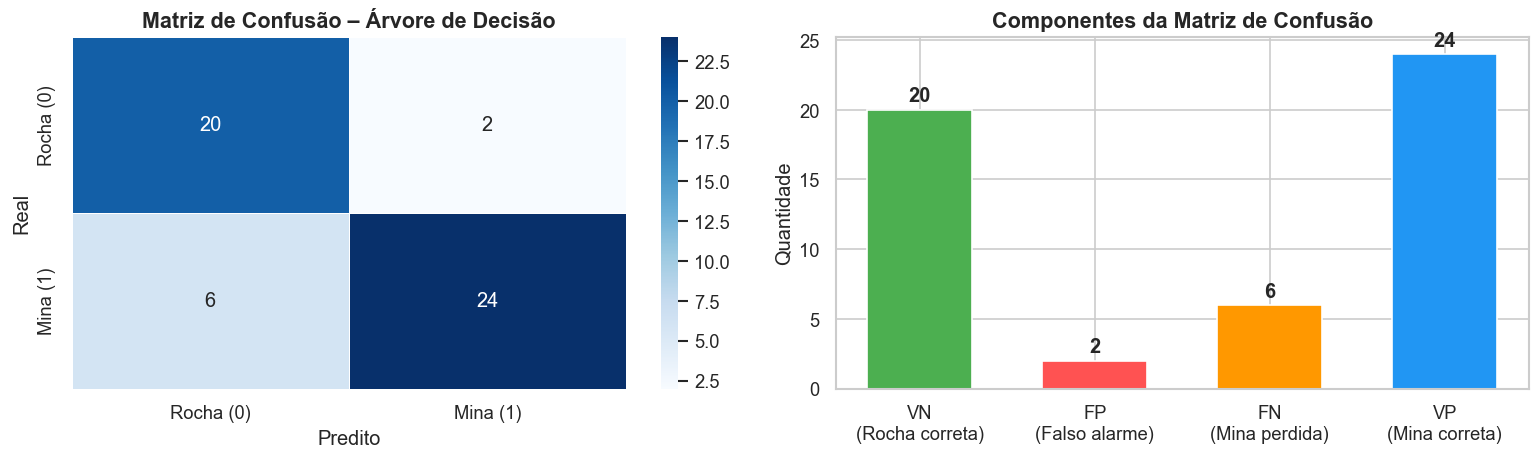


VN=20  FP=2  FN=6  VP=24


In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rocha (0)', 'Mina (1)'],
            yticklabels=['Rocha (0)', 'Mina (1)'],
            ax=axes[0], linewidths=.5)
axes[0].set_title('Matriz de Confusão – Árvore de Decisão', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

# Barras de componentes
labels = ['VN\n(Rocha correta)', 'FP\n(Falso alarme)', 'FN\n(Mina perdida)', 'VP\n(Mina correta)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['#4CAF50', '#FF5252', '#FF9800', '#2196F3']
bars = axes[1].bar(labels, values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Componentes da Matriz de Confusão', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.savefig('../images/arvore_matriz_confusao.png', bbox_inches='tight')
plt.show()

print(f"\nVN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  VP={cm[1,1]}")


## 7. Relatório de Classificação Completo

In [7]:
print(classification_report(y_test, y_pred, target_names=["Rocha (0)", "Mina (1)"]))


              precision    recall  f1-score   support

   Rocha (0)       0.77      0.91      0.83        22
    Mina (1)       0.92      0.80      0.86        30

    accuracy                           0.85        52
   macro avg       0.85      0.85      0.85        52
weighted avg       0.86      0.85      0.85        52



## 8. Validação Cruzada (5-fold)

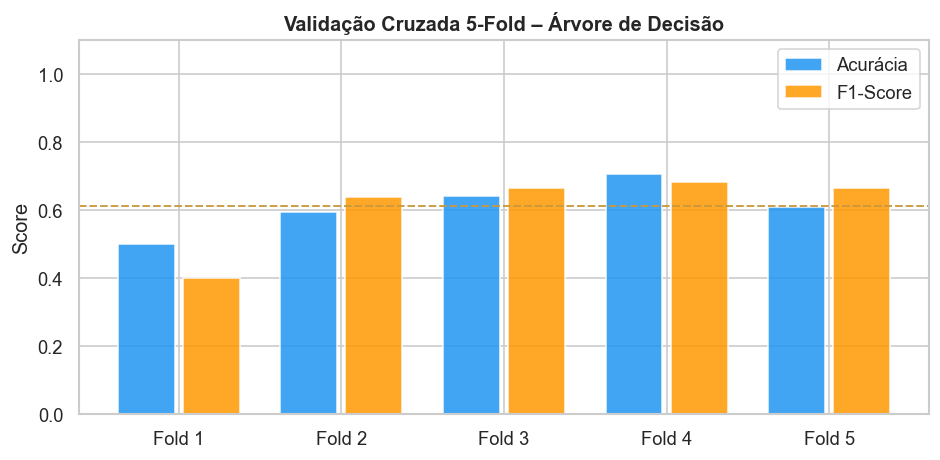

Acurácia CV  → média=0.6110  std=0.0676
F1-Score CV  → média=0.6112   std=0.1066


In [ ]:
cv_acc = cross_val_score(modelo, X, y, cv=5, scoring='accuracy')
cv_f1  = cross_val_score(modelo, X, y, cv=5, scoring='f1')

fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
ax.bar(x - 0.2, cv_acc, 0.35, label='Acurácia', color='#2196F3', alpha=0.85)
ax.bar(x + 0.2, cv_f1,  0.35, label='F1-Score',  color='#FF9800', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(folds)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Validação Cruzada 5-Fold – Árvore de Decisão', fontweight='bold')
ax.legend(); ax.axhline(cv_acc.mean(), color='#2196F3', ls='--', lw=1.2, alpha=0.7)
ax.axhline(cv_f1.mean(),  color='#FF9800',  ls='--', lw=1.2, alpha=0.7)
plt.tight_layout()
plt.savefig('../images/arvore_cv.png', bbox_inches='tight')
plt.show()

print(f"Acurácia CV  → média={cv_acc.mean():.4f}  std={cv_acc.std():.4f}")
print(f"F1-Score CV  → média={cv_f1.mean():.4f}   std={cv_f1.std():.4f}")


## 9. Sumário Final

In [ ]:
sumario = pd.DataFrame({
    "Modelo"           : ["Árvore de Decisão"],
    "Acurácia"         : [round(acc, 4)],
    "Precisão"         : [round(precision, 4)],
    "Recall"           : [round(recall, 4)],
    "F1-Score"         : [round(f1, 4)],
    "ROC-AUC"          : [round(roc_auc, 4)],
    "CV Acurácia (μ)"  : [round(cv_scores.mean(), 4)],
})
print("=== SUMÁRIO – ÁRVORE DE DECISÃO ===")
display(sumario)
print("\nSalve este DataFrame para consolidar com os demais modelos.")


=== SUMÁRIO – ÁRVORE DE DECISÃO ===


,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC-AUC,CV Acurácia (μ)
0,Árvore de Decisão,0.8462,0.9231,0.8,0.8571,0.8621,0.611



✅ Salve este DataFrame para consolidar com os demais modelos.
